# DS 5610 Final Project
## Economic Freedom of the World
Maggie Tu, Roshan Siddartha, Laura Li

In [1]:
import pandas as pd
import numpy as np
import re

# Loading in the Economic Freedom Dataset and inital EDA steps:
    # Code Written by Laura, reviewed by Roshan

# Load the Economic Freedom Index data
freedom_index_df = pd.read_excel('data/economic-freedom-of-the-world-2024-master-index-data-for-researchers-iso.xlsx', header=4)

# Initial look at dataset
print(freedom_index_df.head())

# Drop first column with no informations
freedom_index_df = freedom_index_df.drop(freedom_index_df.columns[0], axis=1)

# Rename the ' Economic Freedom Summary Index' to 'Economic Freedom Index'
freedom_index_df = freedom_index_df.rename(columns={' Economic Freedom Summary Index':'Economic Freedom Index'})

# Basic info check and summary statistics
print(freedom_index_df.info())
print(freedom_index_df.describe())

# Find the number of unique countries and the full year range for the dataset
num_countries = freedom_index_df['Countries'].nunique()
min_year = freedom_index_df['Year'].min()
max_year = freedom_index_df['Year'].max()
print(f"Number of unique countries: {num_countries}")
print(f"Year range: {min_year} to {max_year}")

# Find the number of measures that make up the Economic Freedom Index 
excluded_pattern = r'Year|ISO Code [23]|Countries|Economic Freedom Index|Rank$|Quartile|^data\.\d+$|^data$|Area \d+ Rank|World Bank Region|World Bank Current Income Classification|1990-Present|Size of Government|Legal System & Property Rights -- Without Gender Adjustment|Legal System & Property Rights -- With Gender Adjustment|Sound Money|Freedom to trade internationally|Regulation'
non_excluded_cols = [col for col in freedom_index_df.columns 
                    if not re.search(excluded_pattern, col, re.IGNORECASE)]
print(f"Number of non-excluded columns: {len(non_excluded_cols)}")

# Check for total number of missing values
print("\nMissing Values per Column:")
print(freedom_index_df.isnull().sum())

# Count how many missing Economic Freedom Index values each country has
missing_count = freedom_index_df[freedom_index_df['Economic Freedom Index'].isna()]['Countries'].value_counts()

# List top 10 countries with the most missing values
print("\nTop 10 Countries with Most Missing Economic Freedom Index Values:")
for country, count in missing_count.head(10).items():
    print(f"{country}: {count} missing values")


   Unnamed: 0    Year ISO Code 2 ISO Code 3  Countries  \
0         NaN  2022.0         AL        ALB    Albania   
1         NaN  2022.0         DZ        DZA    Algeria   
2         NaN  2022.0         AO        AGO     Angola   
3         NaN  2022.0         AR        ARG  Argentina   
4         NaN  2022.0         AM        ARM    Armenia   

    Economic Freedom Summary Index   Rank  Quartile  Government consumption  \
0                             7.48   38.0       1.0                8.282353   
1                             4.46  161.0       4.0                3.491176   
2                             4.79  155.0       4.0                7.944118   
3                             4.55  159.0       4.0                6.167647   
4                             7.49   36.0       1.0                7.058824   

    data  ...  Tax compliance  Business regulations  Market openness  \
0  11.84  ...        3.587625              5.379721         6.810619   
1  28.13  ...        4.764764   

Missing values before dropping:
Size of Government                                          272
Legal System & Property Rights -- With Gender Adjustment    142
Sound Money                                                 300
Freedom to trade internationally                            755
Regulation                                                  273
Economic Freedom Index                                      399
dtype: int64

Shape before dropping NA: (4786, 85)
Shape after dropping NA: (4000, 85)
   Year ISO Code 2 ISO Code 3  Countries  Economic Freedom Index   Rank  \
0  2022         AL        ALB    Albania                    7.48   38.0   
1  2022         DZ        DZA    Algeria                    4.46  161.0   
2  2022         AO        AGO     Angola                    4.79  155.0   
3  2022         AR        ARG  Argentina                    4.55  159.0   
4  2022         AM        ARM    Armenia                    7.49   36.0   

   Quartile  Government consumption   data  Tr

C:\Users\laura\AppData\Local\Temp\ipykernel_26324\3001741624.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['Year'] = clean_df['Year'].astype(int)


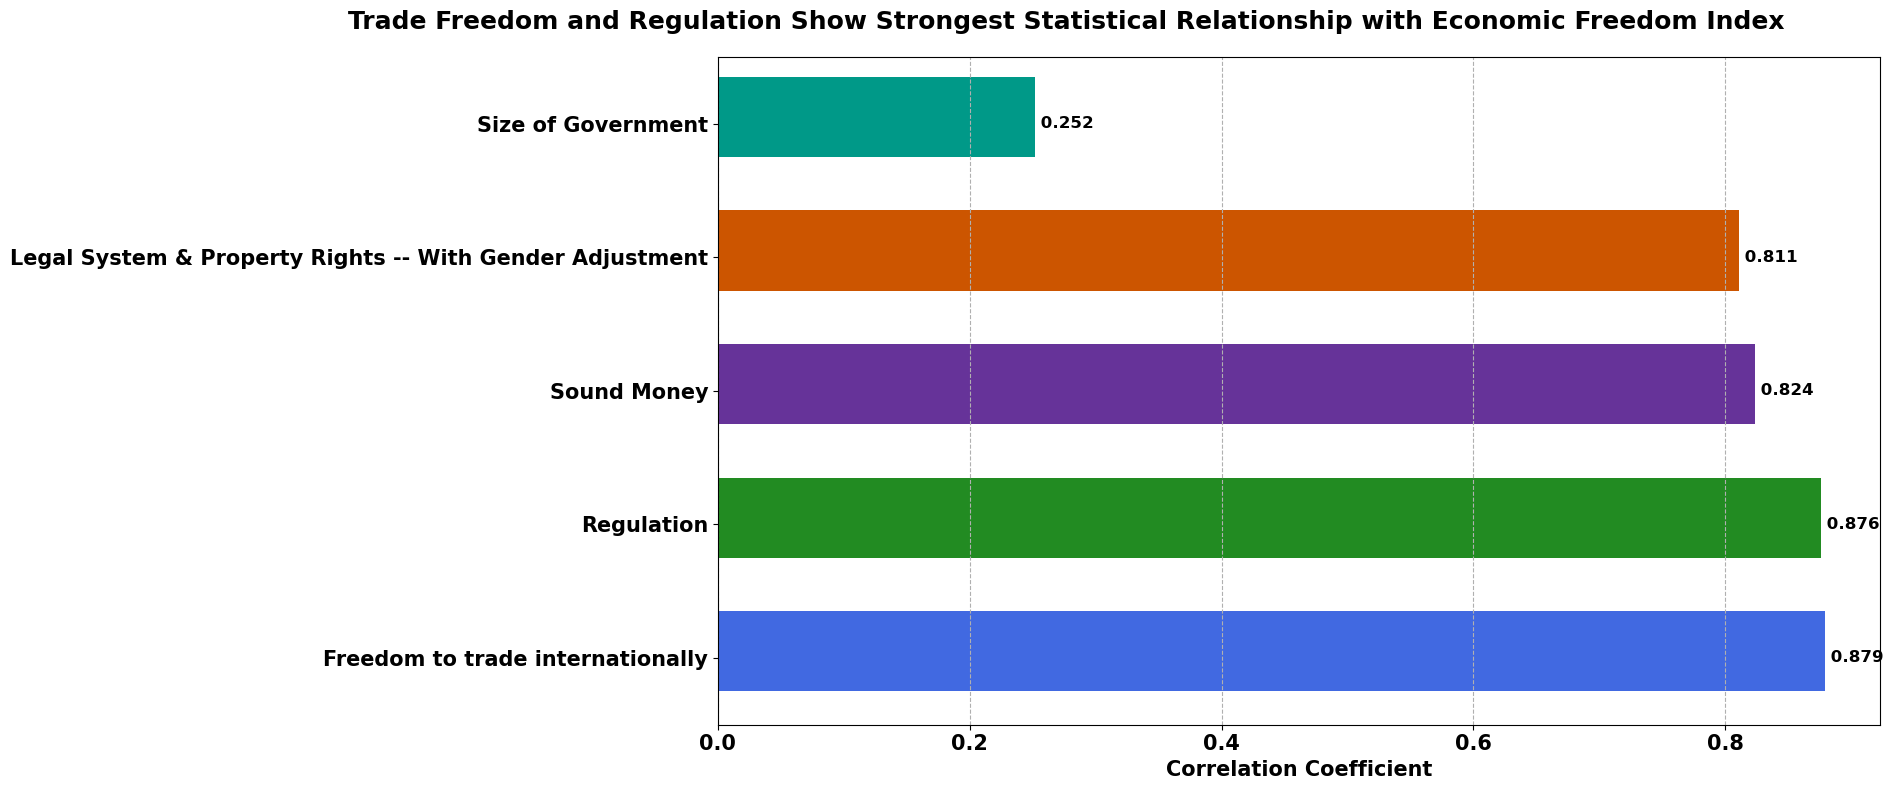

In [2]:
# Creating Visualization 1 (which components of Economic Freedom correlates with the overall index the most) 
    # Written by: Laura, reviewed by: Maggie
import seaborn as sns
import matplotlib.pyplot as plt

# All the categories that make up Economic Freedom are divided into 5 groups (dataset already has this), define the main category columns
category_columns = [
    'Size of Government',
    'Legal System & Property Rights -- With Gender Adjustment',
    'Sound Money', 
    'Freedom to trade internationally',
    'Regulation'
]

# Create a copy of the dataframe with numeric columns only
numeric_df = freedom_index_df.copy()
for col in category_columns + ['Economic Freedom Index']:
    numeric_df[col] = pd.to_numeric(numeric_df[col].replace(' ', pd.NA), errors='coerce')

# Print number of missing values before dropping
print("Missing values before dropping:")
print(numeric_df[category_columns + ['Economic Freedom Index']].isnull().sum())

# Drop rows with missing values in category columns and freedom index
clean_df = numeric_df.dropna(subset=category_columns + ['Economic Freedom Index'])

print(f"\nShape before dropping NA: {numeric_df.shape}")
print(f"Shape after dropping NA: {clean_df.shape}")

# Change the datatype of Year column to int
clean_df['Year'] = clean_df['Year'].astype(int)

# Look at cleaned dataframe
print(clean_df.head())

# Calculate correlations with Economic Freedom Index
correlations = clean_df[category_columns].corrwith(clean_df['Economic Freedom Index']).sort_values(ascending=False)

# Create figure for the plot
plt.figure(figsize=(19, 8))

# Define a color palette
colors = ['#4169E1', '#228B22', '#663399', '#CC5500', '#009988']

# Create horizontal bar plot with different colors
ax = correlations.plot(kind='barh', color=colors)
for patch in ax.patches:
    patch.set_height(0.6)

# Add value labels on the bars 
for i, v in enumerate(correlations):
    ax.text(v, i, f' {v:.3f}', va='center', fontsize=12, weight='bold')

# Add only vertical grid lines
plt.grid(False)
ax.grid(axis='x', linestyle='--')

# Set title and axis labels
plt.title('Trade Freedom and Regulation Show Strongest Statistical Relationship with Economic Freedom Index', 
          fontsize=18, pad=20, weight='bold', x=0.3)
plt.xlabel('Correlation Coefficient', fontsize=15, weight='bold')
plt.ylabel('')  

# Format ticks
ax.tick_params(axis='both', which='major', labelsize=15)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_weight('bold')

plt.tight_layout()

# Print the correlation values
print("\nCorrelations with Economic Freedom Index:")
for component, corr in correlations.items():
    print(f"{component}: {corr:.3f}")


   Year ISO Code 2 ISO Code 3  Countries  Economic Freedom Index   Rank  \
0  2022         AL        ALB    Albania                    7.48   38.0   
1  2022         DZ        DZA    Algeria                    4.46  161.0   
2  2022         AO        AGO     Angola                    4.79  155.0   
3  2022         AR        ARG  Argentina                    4.55  159.0   
4  2022         AM        ARM    Armenia                    7.49   36.0   

   Quartile  Government consumption   data  Transfers and subsidies  ...  \
0       1.0                8.282353  11.84                 7.133515  ...   
1       4.0                3.491176  28.13                 7.817129  ...   
2       4.0                7.944118  12.99                 9.702997  ...   
3       4.0                6.167647  19.03                 5.536785  ...   
4       1.0                7.058824  16.00                 7.882834  ...   

   Tax compliance  Business regulations  Market openness  Business Permits  \
0        3.587

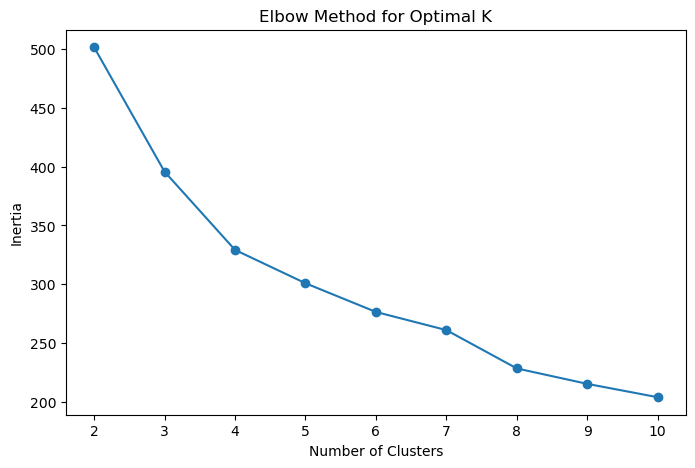


Countries Grouped by Clusters:

Cluster 0:
['Azerbaijan' 'Belarus' 'Belize' 'Bhutan' 'Bolivia'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Burkina Faso' 'China'
 'Comoros' "Côte d'Ivoire" 'Djibouti' 'Ecuador' 'Egypt, Arab Rep.'
 'Eswatini' 'Fiji' 'Guyana' 'Iraq' 'Kuwait' 'Lao PDR' 'Lesotho' 'Liberia'
 'Libya' 'Madagascar' 'Mali' 'Mauritania' 'Namibia' 'Nicaragua' 'Niger'
 'Oman' 'Papua New Guinea' 'Qatar' 'Russian Federation' 'Rwanda' 'Senegal'
 'South Africa' 'Tajikistan' 'Tanzania' 'Timor-Leste' 'Togo' 'Tunisia'
 'Vietnam' 'Zambia']

Cluster 1:
['Albania' 'Armenia' 'Bahamas, The' 'Bahrain' 'Barbados' 'Benin'
 'Brunei Darussalam' 'Bulgaria' 'Cabo Verde' 'Cambodia' 'Chile' 'Colombia'
 'Costa Rica' 'Dominican Republic' 'El Salvador' 'Gambia, The' 'Georgia'
 'Guatemala' 'Honduras' 'India' 'Indonesia' 'Jamaica' 'Jordan'
 'Kazakhstan' 'Kenya' 'Kyrgyz Republic' 'Malaysia' 'Mauritius' 'Mexico'
 'Moldova' 'Mongolia' 'Montenegro' 'Morocco' 'Nepal' 'North Macedonia'
 'Panama' 'Paraguay' 'Pe

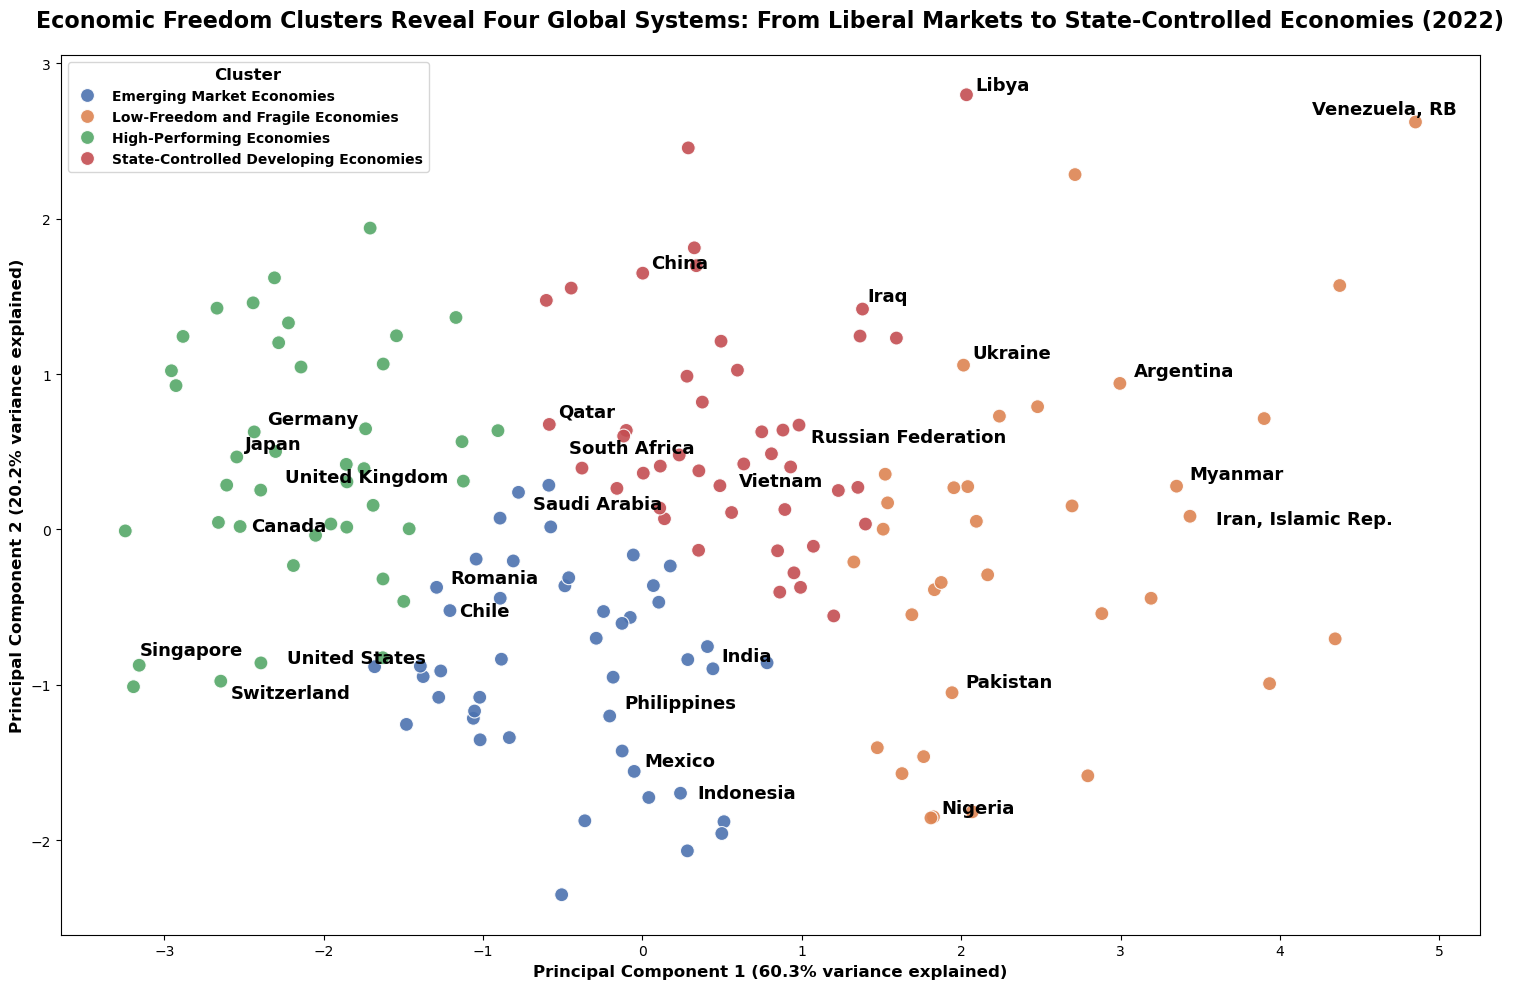

In [3]:
# Creating visualization 2 (clustring countries based on the above 5 categories) 
    # written by Laura, reviewed by: Roshan

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from adjustText import adjust_text
from sklearn.decomposition import PCA

# Keep data from the latest year, and drop NA's
latest_year = freedom_index_df['Year'].max()
freedom_index_df_filtered = freedom_index_df[freedom_index_df['Year'] == latest_year].dropna(subset=category_columns)

# Change the datatype of Year column to int
freedom_index_df_filtered['Year'] = freedom_index_df_filtered['Year'].astype(int)

# Reset index for cleaner display
freedom_index_df_filtered = freedom_index_df_filtered.reset_index(drop=True)

# Look at filtered dataset
print(freedom_index_df_filtered.head())

# Standardize the selected categories
scaler = StandardScaler()
X = scaler.fit_transform(freedom_index_df_filtered[category_columns])

# Find the optimal number of clusters using the Elbow Method
inertia = []
for k in range(2, 11):  
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

# Fit the K-Means model with the chosen number of clusters (4)
kmeans = KMeans(n_clusters=4, random_state=42)
freedom_index_df_filtered['Cluster'] = kmeans.fit_predict(X)

# Inspect the clusters
print("\nCountries Grouped by Clusters:")
for cluster in sorted(freedom_index_df_filtered['Cluster'].unique()):
    print(f"\nCluster {cluster}:")
    print(freedom_index_df_filtered[freedom_index_df_filtered['Cluster'] == cluster]['Countries'].values)

# Reduce to 2 components for visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Compute cluster averages for the 5 economic freedom categories to determine labels for the clusters
cluster_averages = freedom_index_df_filtered.groupby('Cluster')[[
    'Size of Government',
    'Legal System & Property Rights -- With Gender Adjustment',
    'Sound Money',
    'Freedom to trade internationally',
    'Regulation'
]].mean()

# Display the cluster averages
print("Cluster Averages for Economic Freedom Categories:")
print(cluster_averages)

# Define names for the clusters based on the averages and the type of countries that are in each cluster
cluster_names = {
    0: "State-Controlled Developing Economies",
    1: "Emerging Market Economies",
    2: "High-Performing Economies",
    3: "Low-Freedom and Fragile Economies"
}

# Map cluster names to the DataFrame
freedom_index_df_filtered['Cluster_Name'] = freedom_index_df_filtered['Cluster'].map(cluster_names)

# Create a DataFrame for plotting
df_plot = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_plot['Cluster'] = freedom_index_df_filtered['Cluster']
df_plot['Cluster_Name'] = freedom_index_df_filtered['Cluster_Name']
df_plot['Countries'] = freedom_index_df_filtered['Countries']

# Define well-known countries for each cluster (7 from each)
notable_countries = {
    0: ['China', 'Russian Federation', 'Vietnam', 'Iraq', 
        'Libya', 'Qatar', 'South Africa'],  

    1: ['India', 'Indonesia', 'Mexico', 'Saudi Arabia', 
        'Chile', 'Philippines', 'Romania'],  

    2: ['United States', 'Japan', 'Germany', 'United Kingdom', 
        'Canada', 'Singapore', 'Switzerland'],  

    3: ['Argentina', 'Pakistan', 'Nigeria', 'Iran, Islamic Rep.', 
        'Ukraine', 'Venezuela, RB', 'Myanmar'] 
}

# Flatten the dictionary to a single list
all_notable_countries = [country for countries in notable_countries.values() for country in countries]

# Create figure for plotting 
plt.figure(figsize=(15, 10))

# Create scatter plot of the countries by clusters
sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Cluster_Name', 
                palette='deep', s=100, alpha=0.9, legend='full')

# Create texts for adjustText (only label 7 countries from each cluster)
texts = []
for idx, row in df_plot[df_plot['Countries'].isin(all_notable_countries)].iterrows():
    texts.append(plt.text(row['PC1'], row['PC2'], row['Countries'], fontsize=13, fontweight='bold'))

# Adjust text positions to minimize overlap
adjust_text(texts)

# Add title to the plot
plt.title('Economic Freedom Clusters Reveal Four Global Systems: From Liberal Markets to State-Controlled Economies (2022)', 
          fontsize=16, pad=20, weight='bold')

# Add explained variance ratio to axis labels
explained_variance = pca.explained_variance_ratio_ * 100
plt.xlabel(f'Principal Component 1 ({explained_variance[0]:.1f}% variance explained)', 
          fontsize=12, weight='bold')
plt.ylabel(f'Principal Component 2 ({explained_variance[1]:.1f}% variance explained)', 
          fontsize=12, weight='bold')

# Adding legend to identify clusters
legend=plt.legend(title='Cluster', title_fontsize=12, fontsize=14, prop={'weight': 'bold'})
plt.setp(legend.get_title(), fontweight='bold')
plt.tight_layout()
plt.grid(False)
plt.show()



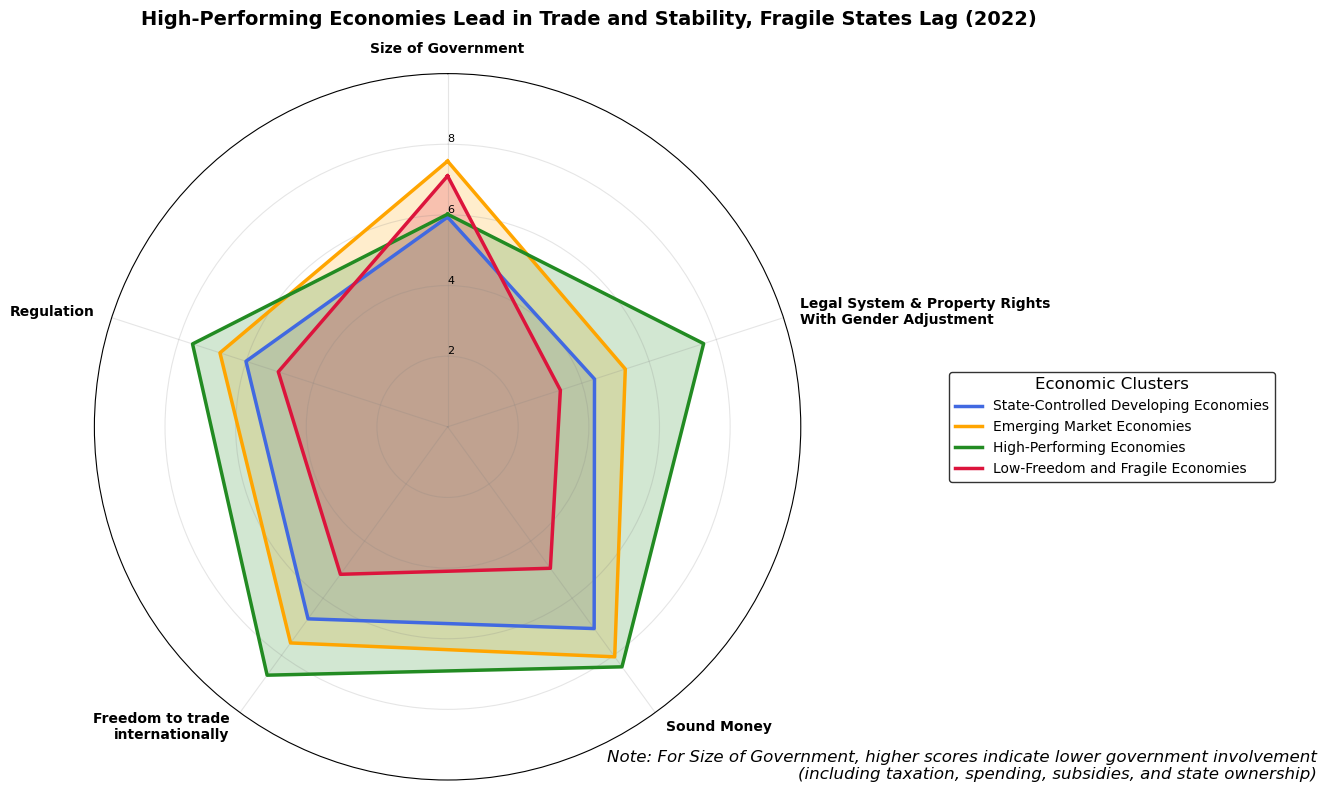

In [4]:
# Creating Visualization 3 (radar showing performance of each cluster for each economic freedom category) 
   # Written by Laura, reviewed by Roshan
from math import pi
import matplotlib.pyplot as plt
import numpy as np

# Compute cluster means and rename indices to cluster names
cluster_means = freedom_index_df_filtered.groupby('Cluster')[category_columns].mean()
cluster_means.index = cluster_means.index.map(cluster_names)

# Define angles for the radar chart
num_vars = len(category_columns)
angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1]

# Define custom colors for each cluster
colors = {
    'High-Performing Economies': '#228B22',      
    'Emerging Market Economies': '#FFA500',     
    'State-Controlled Developing Economies': '#4169E1',  
    'Low-Freedom and Fragile Economies': '#DC143C'      
}

# Initialize the radar chart with white background
fig = plt.figure(figsize=(12, 8), facecolor='white')
ax = fig.add_subplot(111, polar=True)

# Plot each cluster
for name, row in cluster_means.iterrows():
    values = row.tolist()
    values += values[:1]
    
    # Set colors and line width
    ax.plot(angles, values, linewidth=2.5, linestyle='solid', 
            label=name, color=colors[name])
    
    # Fill with semi-transparency
    ax.fill(angles, values, alpha=0.2, color=colors[name])

# Rotate the plot so first axis is at top
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)

# Add category labels 
plt.xticks(angles[:-1], [])  # Remove default labels
for angle, label in zip(angles[:-1], category_columns):
    # Calculate label position
    if angle == 0:
        ha, va = 'center', 'bottom'
    elif 0 < angle < pi:
        ha, va = 'left', 'center'
    elif angle == pi:
        ha, va = 'center', 'top'
    else:
        ha, va = 'right', 'center'
    
    # Add label with wrapping for long text
    label = label.replace(' -- ', '\n')  # Break long labels
    ax.text(angle, 10.5, label, 
            ha=ha, va=va,
            fontsize=10,
            fontweight='bold',
            wrap=True)

# Customize radial axes
ax.set_ylim(0, 10)
ax.set_rgrids([2, 4, 6, 8], angle=0,
              labels=['2', '4', '6', '8'],
              fontsize=8)

# Add subtle gridlines
ax.grid(True, color='gray', alpha=0.2)

# Add title with some space
plt.title('High-Performing Economies Lead in Trade and Stability, Fragile States Lag (2022)', 
          size=14, fontweight='bold', pad=35, x=0.7)

# Adding legend
plt.legend(title="Economic Clusters", 
          loc='center left',
          bbox_to_anchor=(1.2, 0.5),
          fontsize=10,
          title_fontsize=12,
          frameon=True,
          edgecolor='black')

# Add note about Size of Government scoring
plt.figtext(1.10, 0.02, 
            'Note: For Size of Government, higher scores indicate lower government involvement\n(including taxation, spending, subsidies, and state ownership)',
            ha='right', fontsize=12, style='italic')

# Adjust layout to prevent label cutoff
plt.tight_layout()

plt.show()

In [5]:
# Prepping economic freedom dataset for later merging and analysis
    # Code written by Roshan, reviewed by Maggie

# Only keeping the required columns of Year, Country, Economic Freedom Index
req_columns_free = ['Year','Countries','Economic Freedom Index']
freedom_index_df = freedom_index_df[req_columns_free]

# Looking at filtered dataset 
print(freedom_index_df.head())

# Display rows with missing 'Year' values
rows_with_nan = freedom_index_df[freedom_index_df['Year'].isna()]
print("Rows with missing 'Year':")
print(rows_with_nan)

# Drop rows with missing 'Year'
freedom_index_df = freedom_index_df.dropna(subset=['Year'])

# Change the datatype of Year column to int
freedom_index_df['Year'] = freedom_index_df['Year'].astype(int)

# Filter the DataFrame for year range 2015-2022
freedom_index_df = freedom_index_df[(freedom_index_df['Year']>=2015) & (freedom_index_df['Year']<=2022)]

# Checking the number of null values in the base dataset
freedom_index_df.isna().sum()

# Checking what and where the missing values are
freedom_index_df[freedom_index_df['Economic Freedom Index'].isna()]

# Dropping the rows where there are null values
freedom_index_df.dropna(inplace=True)

# Sort the dataset so that it looks neat and organized
freedom_index_df = freedom_index_df.sort_values(by=['Year','Countries']).reset_index(drop=True)

# Renaming Hong Kong for better readibility in the freedom_index_df
freedom_index_df['Countries'] = freedom_index_df['Countries'].replace('Hong Kong SAR, China', 'Hong Kong')

# Looking at cleaned dataset
print(freedom_index_df.head())
print(freedom_index_df.isnull().sum())

     Year  Countries  Economic Freedom Index
0  2022.0    Albania                    7.48
1  2022.0    Algeria                    4.46
2  2022.0     Angola                    4.79
3  2022.0  Argentina                    4.55
4  2022.0    Armenia                    7.49
Rows with missing 'Year':
      Year Countries  Economic Freedom Index
4785   NaN       NaN                     NaN
   Year  Countries  Economic Freedom Index
0  2015    Albania                    7.64
1  2015    Algeria                    4.68
2  2015     Angola                    5.25
3  2015  Argentina                    4.95
4  2015    Armenia                    7.43
Year                      0
Countries                 0
Economic Freedom Index    0
dtype: int64


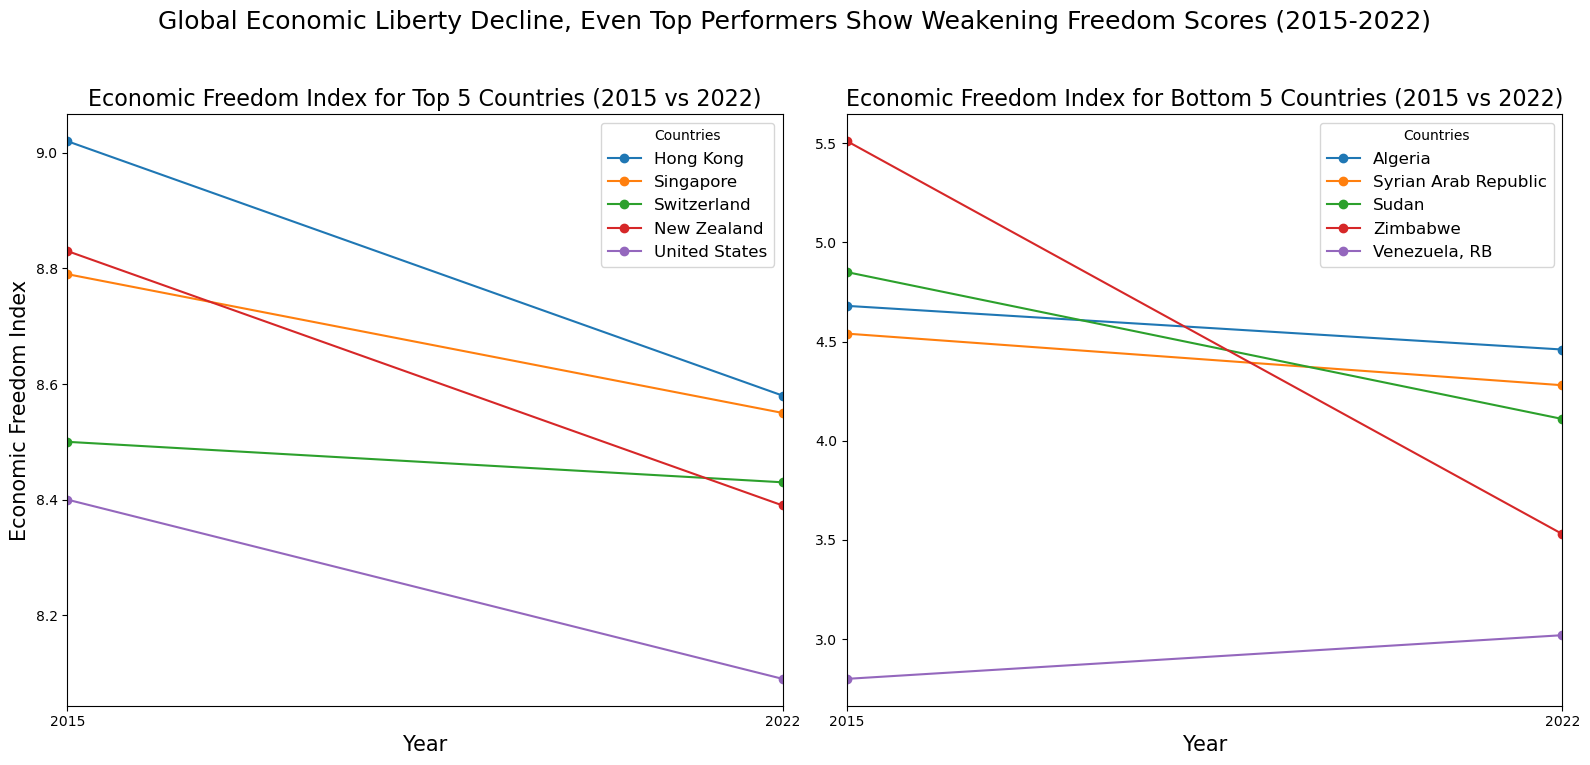

In [6]:
# Creating visualization 4 (Economic Freedom Index Changes for Top 5 and Bottom 5 Countries (2015 to 2022))
    # Code written by Maggie, reviewed by Roshan

# Find top 5 and bottom 5 ranking countries in 2022
top_5_countries_2022 = freedom_index_df[freedom_index_df['Year'] == 2022].sort_values(by='Economic Freedom Index', ascending=False).head(5)['Countries'].tolist()
bottom_5_countries_2022 = freedom_index_df[freedom_index_df['Year'] == 2022].sort_values(by='Economic Freedom Index', ascending=False).tail(5)['Countries'].tolist()

# Filter for the selected top and bottom 5 countries in the year 2015 and year 2022 
selected_years = [2015, 2022]
filtered_df_top = freedom_index_df[(freedom_index_df['Countries'].isin(top_5_countries_2022)) & (freedom_index_df['Year'].isin(selected_years))]
filtered_df_bottom = freedom_index_df[(freedom_index_df['Countries'].isin(bottom_5_countries_2022)) & (freedom_index_df['Year'].isin(selected_years))]

# Create subplots for Top 5 and Bottom 5 ranking countries
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot for top 5 countries
for Countries in top_5_countries_2022:
    data = filtered_df_top[filtered_df_top['Countries'] == Countries]
    axes[0].plot(data['Year'], data['Economic Freedom Index'], marker='o', label=Countries)

axes[0].set_title('Economic Freedom Index for Top 5 Countries (2015 vs 2022)', fontsize=16)
axes[0].set_xlabel('Year', fontsize=15)
axes[0].set_ylabel('Economic Freedom Index', fontsize=15)
axes[0].legend(title='Countries', fontsize=12)
axes[0].grid(False)  # Remove gridlines
axes[0].set_xticks([2015, 2022])  # Show only 2015 and 2022
axes[0].set_xlim(2015, 2022)  # Remove padding

# Plot for bottom 5 countries
for Countries in bottom_5_countries_2022:
    data = filtered_df_bottom[filtered_df_bottom['Countries'] == Countries]
    axes[1].plot(data['Year'], data['Economic Freedom Index'], marker='o', label=Countries)

axes[1].set_title('Economic Freedom Index for Bottom 5 Countries (2015 vs 2022)', fontsize=16)
axes[1].set_xlabel('Year', fontsize=15)
axes[1].legend(title='Countries', fontsize=12)
axes[1].grid(False)  # Remove gridlines
axes[1].set_xticks([2015, 2022])  # Show only 2015 and 2022
axes[1].set_xlim(2015, 2022)  # Remove padding

# Set layout and show plot
plt.suptitle('Global Economic Liberty Decline, Even Top Performers Show Weakening Freedom Scores (2015-2022)', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


        Entity Code  Year  Cantril ladder score
0  Afghanistan  AFG  2015                3.3600
1  Afghanistan  AFG  2016                3.7940
2  Afghanistan  AFG  2017                3.6315
3  Afghanistan  AFG  2018                3.2033
4  Afghanistan  AFG  2019                2.5669
Countries      0
Year           0
Life Ladder    0
dtype: int64


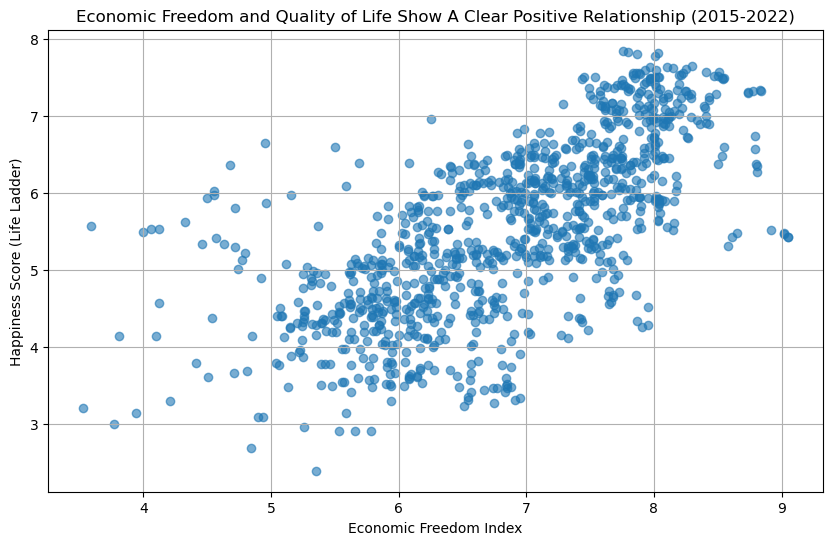

In [7]:
# Creating visualization 5 (Economic Freedom and Life Satisfaction)
    # Code written by Maggie, reviewed by Laura

# Load the world happiness dataset
happiness_df = pd.read_csv('data/happiness-cantril-ladder.csv')

# Initial look at happiness dataset
print(happiness_df.head())

# Drop the 'Code' column
happiness_df.drop(columns=['Code'], inplace=True)

# Drop rows with missing values in ladder score
happiness_df.dropna(subset=['Cantril ladder score'], inplace=True)

# Rename columns to prep for merge and better readability
happiness_df.rename(columns={'Entity': 'Countries', 'Cantril ladder score': 'Life Ladder'}, inplace=True)

# check missing value
print(happiness_df.isna().sum())

# Merge the two dataframes on 'Year' and 'Country'
fh_merged_df = pd.merge(freedom_index_df, happiness_df, how='inner', on=['Year', 'Countries'])

# Scatter plot for the relationship between Economic Freedom and Happiness
plt.figure(figsize=(10, 6))
plt.scatter(fh_merged_df['Economic Freedom Index'], fh_merged_df['Life Ladder'], alpha=0.6)
plt.xlabel('Economic Freedom Index')
plt.ylabel('Happiness Score (Life Ladder)')
plt.title('Economic Freedom and Quality of Life Show A Clear Positive Relationship (2015-2022)')
plt.grid(True)
plt.show()

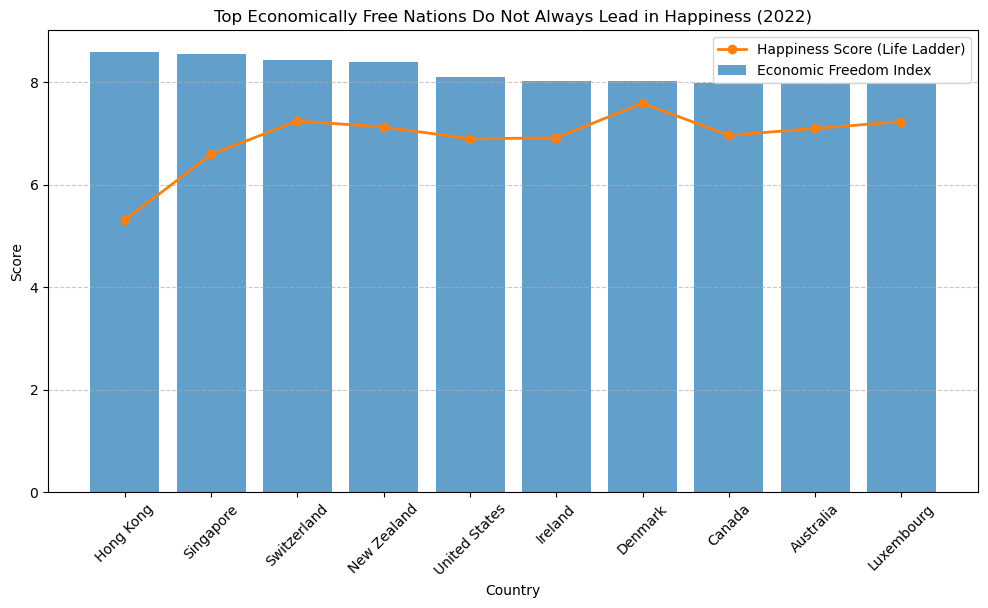

In [8]:
# Creating visualization 6 (Top 10 Countries by Economic Freedom and Their Happiness Scores (2022))
    # Written by: Maggie, reviewed by: Roshan
import matplotlib.colors as mcolors

# Filter data for 2022 
fh_2022 = fh_merged_df[fh_merged_df['Year'] == 2022]

# Sort by Economic Freedom Index and select top 10 countries
top_10_2022 = fh_2022.sort_values(by='Economic Freedom Index', ascending=False).head(10)

# Define colorblind-friendly colors
color_blind_palette = mcolors.TABLEAU_COLORS

# Plot bar chart
plt.figure(figsize=(12, 6))
plt.bar(top_10_2022['Countries'], top_10_2022['Economic Freedom Index'], alpha=0.7, label='Economic Freedom Index', color=color_blind_palette['tab:blue'])
plt.plot(top_10_2022['Countries'], top_10_2022['Life Ladder'], color=color_blind_palette['tab:orange'], marker='o', linewidth=2, label='Happiness Score (Life Ladder)')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.ylabel('Score')
plt.title('Top Economically Free Nations Do Not Always Lead in Happiness (2022)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [9]:
# Loading in Healthcare dateset and merging with economic freedom dataset
    # Written by Roshan, reviewed by Laura

# Loading in healthcare dataset
health_df = pd.read_csv('data/total-healthcare-expenditure-gdp.csv')

# Taking an initial look at the datset
print(health_df.head())

# Renaming Entity column to Countries to match with Economic Freedom dataset
health_df.rename(columns={'Entity':'Countries'},inplace=True)

# Data cleaning
print("Missing values :")
print(health_df.isna().sum())
print("Value counts of the missing values :")
print(health_df[health_df['Code'].isna()]['Countries'].value_counts())

# Since the missing codes belong to continents and regions that are not individual countries, I'm gonna drop them.
health_df.dropna(inplace=True)

# Checking to see if there's anymore missing values
print("Missing values after cleaning :")
print(health_df.isna().sum())

# Checking if there's any duplicate values
print("Number of duplicate values :")
print(health_df.duplicated().sum()) # No duplicate values

# Merging healthcare dataset with economic freedom dataset on the columns Year and Countries, only keeping rows where they match
merged_df = pd.merge(freedom_index_df,health_df,on=['Year','Countries'], how='inner')

# Create a list of top ten countries with highest economic freedom index in 2021
l2021 = []
l2021 = list(freedom_index_df[freedom_index_df['Year']==2021].sort_values(by='Economic Freedom Index',ascending=False).iloc[:10]['Countries'])

# Creating a subset of the merged healthcare/economic freedom dataset of those 10 countries in the year 2021
df2021 = merged_df[merged_df['Countries'].isin(l2021)]

# Only keep data in 2021
df2021 = df2021[df2021['Year']==2021]
df2021.sort_values(by='Economic Freedom Index',ascending=False,inplace=True)

# Printing first 5 rows of this subset 
print(df2021.head())

        Entity Code  Year  \
0  Afghanistan  AFG  2002   
1  Afghanistan  AFG  2003   
2  Afghanistan  AFG  2004   
3  Afghanistan  AFG  2005   
4  Afghanistan  AFG  2006   

   Current health expenditure (CHE) as percentage of gross domestic product (GDP) (%)  
0                                               9.44                                   
1                                               8.94                                   
2                                               9.81                                   
3                                               9.95                                   
4                                              10.62                                   
Missing values :
Countries                                                                               0
Code                                                                                  132
Year                                                                                    0
Current he

In [10]:
# Loading in GDP dataset and merging with current df2021 (economic freedom and healthcare expenditure)
    # written by: Roshan, reviewed by: Maggie
 
# Reading in GDP dataset
gdp_df = pd.read_csv('data/national-gdp-wb.csv')

# Printing first 5 rows of the GDP dataset
print(gdp_df.head())

# Data cleaning
print("Missing values :")
print(gdp_df.isna().sum())
print("Value counts of the missing values :")
print(gdp_df[gdp_df['Code'].isna()]['Entity'].value_counts())

# Since the missing codes belong to continents and regions that are not individual countries, I'm gonna drop them.
gdp_df.dropna(inplace=True)

# Checking to see if there's anymore missing values
print("Missing values after cleaning :")
print(gdp_df.isna().sum())

# Checking if there's any duplicate values
print("Number of duplicate values :")
print(gdp_df.duplicated().sum()) # No duplicate values

# Creating a second merged dataset with the 2021 subset and GDP dataset
merged_df2 = pd.merge(df2021,gdp_df,left_on='Countries',right_on='Entity',how='inner')

# Printing first 5 rows of the 2nd merged dataset
print(merged_df2.head())

# Renaming the columns for better readability
merged_df2.rename(columns={'GDP, PPP (constant 2017 international $)':'GDP 2021','Year_x':'Year','Current health expenditure (CHE) as percentage of gross domestic product (GDP) (%)':'Health Expenditure percentage'},inplace=True)

# Dropping unnecessary columns
merged_df2.drop(columns=['Code_x', 'Code_y', 'Entity','Year_y'],inplace=True)


                Entity Code  Year  GDP, PPP (constant 2017 international $)
0          Afghanistan  AFG  2021                              6.080174e+10
1              Albania  ALB  2021                              4.103912e+10
2              Algeria  DZA  2021                              4.872450e+11
3               Angola  AGO  2021                              2.039810e+11
4  Antigua and Barbuda  ATG  2021                              1.911098e+09
Missing values :
Entity                                       0
Code                                        13
Year                                         0
GDP, PPP (constant 2017 international $)     0
dtype: int64
Value counts of the missing values :
Entity
East Asia and Pacific (WB)           1
Europe and Central Asia (WB)         1
European Union (27)                  1
High-income countries                1
Latin America and Caribbean (WB)     1
Low-income countries                 1
Lower-middle-income countries        1
Middle Ea

In [11]:
# Loading in population dataset and merging with current merged_df2 (economic freedom, healthcare, GDP)
    # written by: Roshan, reviewed by: Laura

# Loading in population dataset
pop_df = pd.read_csv('data/population.csv')

# Printing first 5 rows of the population dataset
print(pop_df.head())

# Renaming columns for better readability and to prep for merging 
pop_df.rename(columns={'Entity':'Countries','Population (historical)':'Population'},inplace=True)

# Data cleaning
print("Missing values :")
print(pop_df.isna().sum())
print("Value counts of the missing values :")
print(pop_df[pop_df['Code'].isna()]['Countries'].value_counts())

# Since the missing codes belong to continents and regions that are not individual countries, I'm gonna drop them.
pop_df.dropna(inplace=True)

# Checking to see if there's anymore missing values
print("Missing values after cleaning :")
print(pop_df.isna().sum())

#Checking to see if there's any duplicate values
print("Number of duplicate values :")
print(pop_df.duplicated().sum()) # No duplicate values

# Merging the 2nd merged dataset with the population dataset on Year and Countries
merged_df3 = pd.merge(merged_df2,pop_df,on=['Year','Countries'],how='inner')

# Printing first 5 rows of the 3rd merged dataset
print(merged_df3.head())

# Dropping Code column because we won't be needing it
merged_df3 = merged_df3.drop(columns='Code')

# Creating a new column for GDP per Capita by dividing GDP by Population
merged_df3['GDP per capita'] = merged_df3['GDP 2021']/merged_df3['Population']

# Creating a new column for health expenditure percentage by diving the expenditure in usd by 100
merged_df3['Health Expenditure in usd'] = merged_df3['Health Expenditure percentage']*merged_df3['GDP 2021']/100

# Printing first 5 rows of 3rd merged dataset with the newly created columns
print(merged_df3.head())

        Entity Code  Year  Population (historical)
0  Afghanistan  AFG  2019                 37856126
1  Afghanistan  AFG  2020                 39068978
2  Afghanistan  AFG  2021                 40000411
3  Afghanistan  AFG  2022                 40578846
4  Afghanistan  AFG  2023                 41454762
Missing values :
Countries       0
Code          105
Year            0
Population      0
dtype: int64
Value counts of the missing values :
Countries
Africa                                  5
Latin America and the Caribbean (UN)    5
South America (excl. Brazil)            5
South America                           5
Oceania (UN)                            5
Oceania                                 5
Northern America (UN)                   5
North America                           5
Lower-middle-income countries           5
Low-income countries                    5
High-income countries                   5
Africa (UN)                             5
European Union (27)                     5

In [13]:
# Loading in healthy diet dataset and merging with current merged_df3 (economic freedom, Healthcare, GDP, population)
    # written by: Roshan, reviewed by: Maggie
# Loading the healthy diet dataset
diet_df = pd.read_csv('data/share-healthy-diet-unaffordable.csv')

# Printing first 5 rows of healthy diet dataset
print(diet_df.head())

# Data cleaning
print("Missing values :")
print(diet_df.isna().sum())
print("Value counts of the missing values :")
print(diet_df[diet_df['Code'].isna()]['Countries'].value_counts())

# Since the missing codes belong to continents and regions that are not individual countries, I'm gonna drop them.
diet_df.dropna(inplace=True)

# Checking to see if there's anymore missing values
print("Missing values after cleaning :")
print(diet_df.isna().sum())

# Checking to see if there's any duplicate values
print("Number of duplicate values :")
print(diet_df.duplicated().sum()) # No duplicate values

# Dropping unnecessary column Code
diet_df.drop(columns='Code',inplace=True)

# Merging the 3rd merged dataset with the healthy diet dataset
df = pd.merge(merged_df3,diet_df,on=['Countries','Year'],how='inner')

# Printing first 5 rows of the final merged dataset
print(df.head())

   Countries Code  Year  \
0    Albania  ALB  2021   
1    Algeria  DZA  2021   
2     Angola  AGO  2021   
3    Armenia  ARM  2021   
4  Australia  AUS  2021   

   Share of the population who cannot afford a healthy diet  
0                                               12.6         
1                                               18.7         
2                                               71.7         
3                                               54.1         
4                                                3.2         
Missing values :
Countries                                                    0
Code                                                        11
Year                                                         0
Share of the population who cannot afford a healthy diet     0
dtype: int64
Value counts of the missing values :
Countries
East Asia & Pacific (WB)           1
Europe & Central Asia (WB)         1
High-income countries              1
Latin America & Caribbean

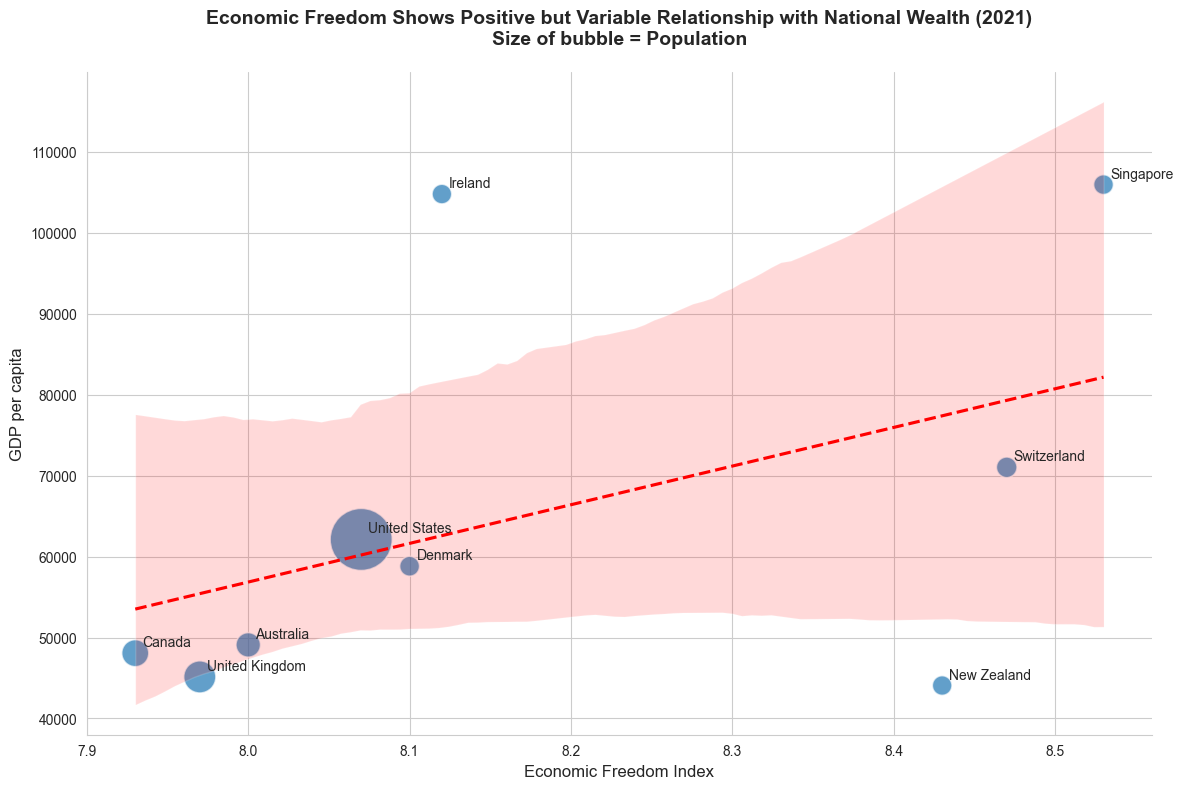

In [6]:
# Creating Visualization 7 (economic freedom and GDP per capital)
    # Written by: Roshan, reviewed by: Laura
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(12, 8))

# Create scatter plot
scatter = sns.scatterplot(data=df,
                         x='Economic Freedom Index',
                         y='GDP per capita',
                         size='Population',  
                         sizes=(200, 2000),
                         alpha=0.7,
                         legend=False)  # remove legend

# Add country labels
for idx, row in df.iterrows():
    plt.annotate(row['Countries'], 
                (row['Economic Freedom Index'], row['GDP per capita']),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=10)

# Customize the plot
plt.title('Economic Freedom Shows Positive but Variable Relationship with National Wealth (2021)\nSize of bubble = Population', 
         pad=20, 
         fontsize=14, 
         fontweight='bold')

plt.xlabel('Economic Freedom Index', fontsize=12)
plt.ylabel('GDP per capita (USD)', fontsize=12)

# Add trend line
sns.regplot(data=df,
            x='Economic Freedom Index',
            y='GDP per capita',
            scatter=False,
            color='red',
            line_kws={'linestyle': '--'})

# Adjust layout
plt.tight_layout()

# Remove top and right spines
sns.despine()

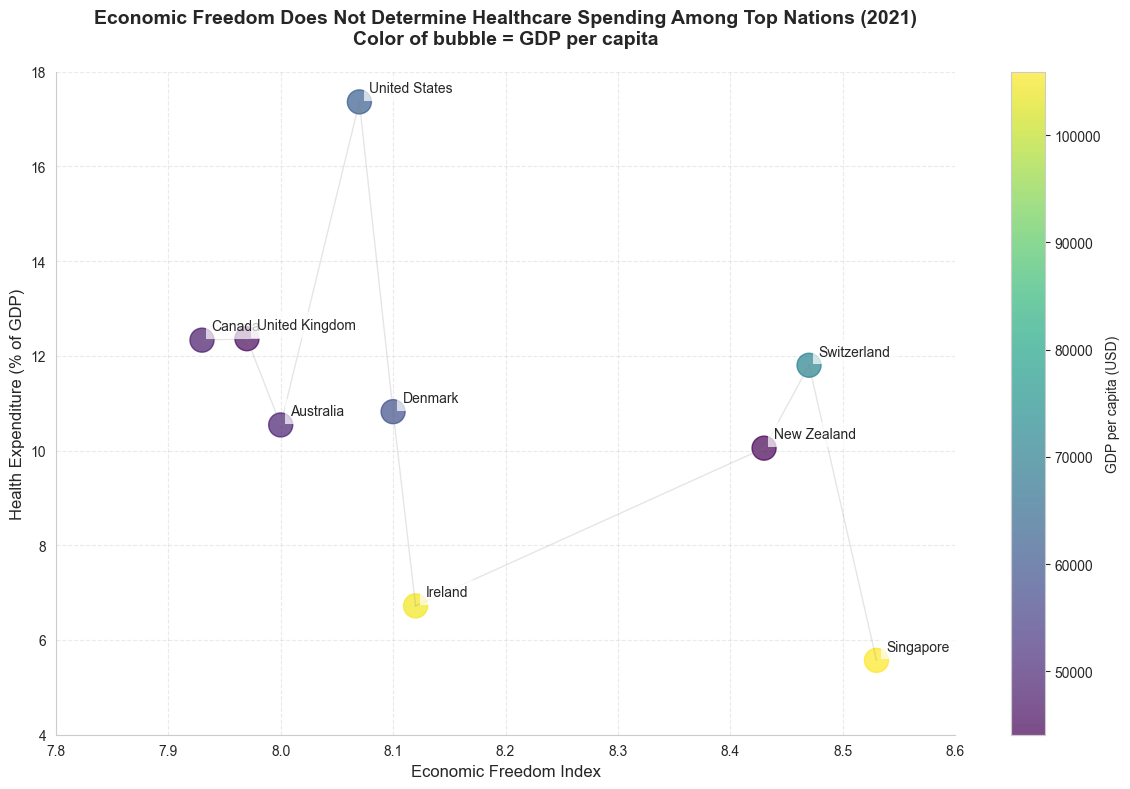

In [7]:
# Creating Visualization 8 (Economic freedom and health expenditure)
    # Written by: Roshan, reviewed by: Maggie
# Sort by Economic Freedom Index
df_sorted = df.sort_values('Economic Freedom Index')

# Set style
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(12, 8))

# Create gradient color for lines based on GDP per capita
gdp_norm = (df_sorted['GDP per capita'] - df_sorted['GDP per capita'].min()) / \
           (df_sorted['GDP per capita'].max() - df_sorted['GDP per capita'].min())

# Create the connecting lines
for i in range(len(df_sorted)-1):
    plt.plot([df_sorted['Economic Freedom Index'].iloc[i], 
              df_sorted['Economic Freedom Index'].iloc[i+1]],
             [df_sorted['Health Expenditure percentage'].iloc[i], 
              df_sorted['Health Expenditure percentage'].iloc[i+1]],
             color='gray', alpha=0.2, linewidth=1)

# Create main scatter plot with custom colors
scatter = plt.scatter(df_sorted['Economic Freedom Index'],
                     df_sorted['Health Expenditure percentage'],
                     c=df_sorted['GDP per capita'],
                     s=300,
                     cmap='viridis',
                     alpha=0.7)

# Add country labels with white background for better readability
for idx, row in df_sorted.iterrows():
    plt.annotate(row['Countries'],
                (row['Economic Freedom Index'], row['Health Expenditure percentage']),
                xytext=(7, 7),
                textcoords='offset points',
                fontsize=10,
                bbox=dict(facecolor='white', 
                         edgecolor='none',
                         alpha=0.7))

# Customize plot
plt.title('Economic Freedom Does Not Determine Healthcare Spending Among Top Nations (2021)\nColor of bubble = GDP per capita', 
         pad=20, 
         fontsize=14, 
         fontweight='bold')

plt.xlabel('Economic Freedom Index', fontsize=12)
plt.ylabel('Health Expenditure (% of GDP)', fontsize=12)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('GDP per capita (USD)', fontsize=10)

# Customize grid
plt.grid(True, linestyle='--', alpha=0.4)

# Set axis limits with some padding
plt.xlim(7.8, 8.6)
plt.ylim(4, 18)

# Adjust layout
plt.tight_layout()

# Remove top and right spines
sns.despine()

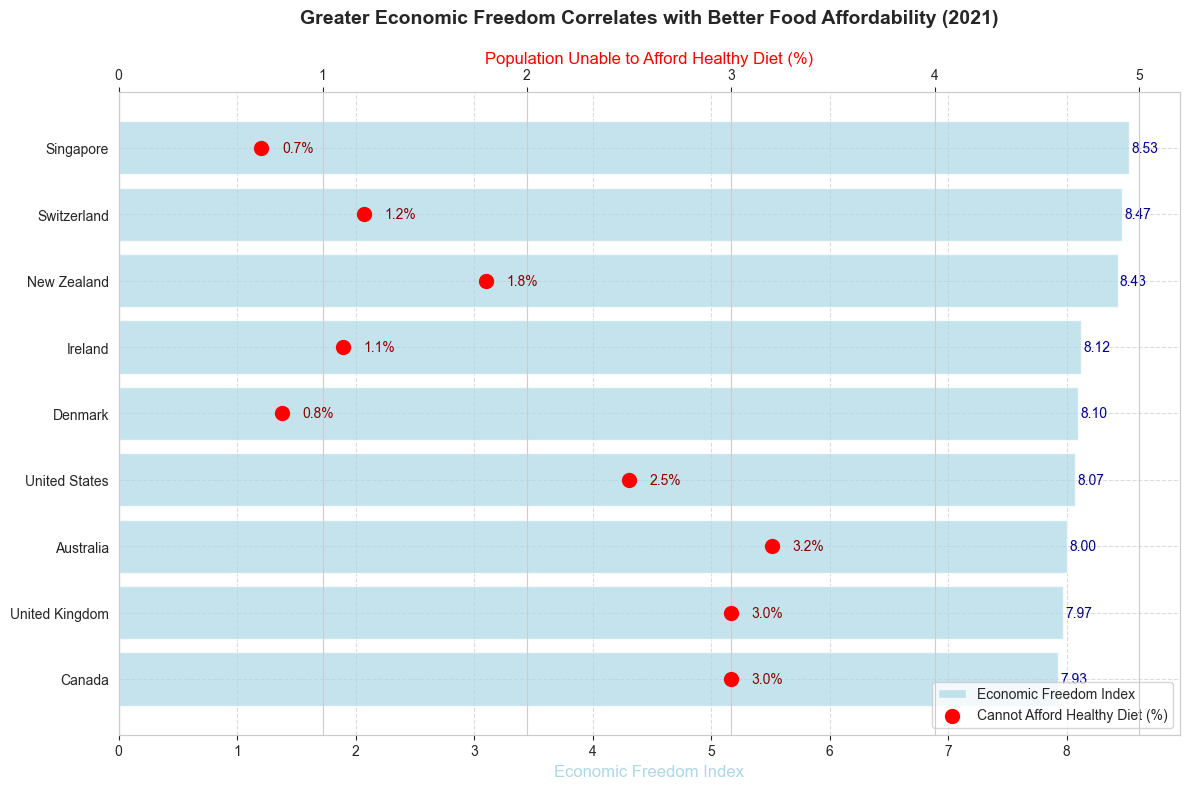

In [8]:
# Creating visualization 9 (economic freedom and food affordability)
    # Written by: Roshan, reviewed by: Laura

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(12, 8))

# Create bars for Economic Freedom
bars = ax1.barh(df_sorted['Countries'], 
                df_sorted['Economic Freedom Index'],
                color='lightblue',
                alpha=0.7,
                label='Economic Freedom Index')

# Create second axis for inability to afford healthy diet
ax2 = ax1.twiny()
points = ax2.scatter(df_sorted['Share of the population who cannot afford a healthy diet'],
                    df_sorted['Countries'],
                    color='red',
                    s=100,
                    label='Cannot Afford Healthy Diet (%)')

# Add x-axis labels and title
ax1.set_xlabel('Economic Freedom Index', color='lightblue', fontsize=12)
ax2.set_xlabel('Population Unable to Afford Healthy Diet (%)', color='red', fontsize=12)
plt.title('Greater Economic Freedom Correlates with Better Food Affordability (2021)', 
         pad=20, 
         fontsize=14, 
         fontweight='bold')

# Add value labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax1.text(width + 0.02, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}',
             ha='left', va='center',
             color='darkblue',
             fontsize=10)

# Add value labels for scatter points
for i, value in enumerate(df_sorted['Share of the population who cannot afford a healthy diet']):
    ax2.text(value + 0.1, i,  
             f'{value:.1f}%',
             ha='left', va='center',
             color='darkred',
             fontsize=10)

# Customize axes
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_axisbelow(True)

# Set x-axis limit for second axis to accommodate labels
max_affordability = df_sorted['Share of the population who cannot afford a healthy diet'].max()
ax2.set_xlim(0, max_affordability + 2)  

# Create combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, 
          loc='lower right',
          fontsize=10)

plt.tight_layout()